# Monte Carlo Simulation of a Gacha Systems 
Simulated by Alex Hoang

In [1]:
# Import necessary libraries
import json # Used for caching results
from pathlib import Path # file path navigation

# Math and plotting
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Global variables

SEED = 42
N_TRIALS = 100000

# Banner values
P0 = 0.008                  # base 5-star rate
HARD_PITY = 80              # both banners
CHAR_ONSETS = (50, 60, 70)  # soft-pity onsets we'll try
CHAR_ONSET_BASELINE = 60
WEAPON_ONSET = 65           # fixed onset for weapon banner

# Directory paths
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Check variables
print(f"SEED = {SEED}, N_TRIALS = {N_TRIALS}")
print(f"Character onsets: {CHAR_ONSETS} (baseline {CHAR_ONSET_BASELINE})")
print(f"Weapon onset: {WEAPON_ONSET}")

SEED = 42, N_TRIALS = 100000
Character onsets: (50, 60, 70) (baseline 60)
Weapon onset: 65


## Model Setup
Section 2 of the report: soft-pity ramp, banner parameters, and a visualization of the rate schedules.

In [3]:
# Calculates and returns the per-pull 5-star probability array (the soft-pity ramp)
def per_pull_probability(onset, hard_pity=HARD_PITY, p0=P0):
    p = np.zeros(hard_pity + 1)
    for n in range(1, hard_pity + 1):
        if n < onset:
            p[n] = p0
        elif n == hard_pity:
            p[n] = 1.0
        else:
            p[n] = p0 + (n - onset) / (hard_pity - onset) * (1.0 - p0)
    return p

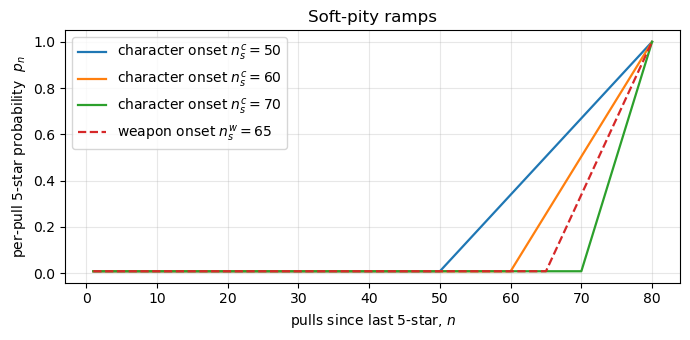

In [4]:
# This graph goes unused. It's just a visualization of the soft-pity ramp
# and was used to review graphing syntax.

# Plot the three character ramps and the weapon ramp
fig, ax = plt.subplots(figsize=(7, 3.5))
for onset in CHAR_ONSETS:
    p = per_pull_probability(onset)
    ax.plot(np.arange(1, HARD_PITY + 1), p[1:], lw=1.6,
            label=f"character onset $n_s^c={onset}$")
p_w = per_pull_probability(WEAPON_ONSET)

# Plotting ramps
ax.plot(np.arange(1, HARD_PITY + 1), p_w[1:], lw=1.6, ls="--",
        label=f"weapon onset $n_s^w={WEAPON_ONSET}$")
ax.set_xlabel("pulls since last 5-star, $n$")
ax.set_ylabel("per-pull 5-star probability  $p_n$")
ax.set_title("Soft-pity ramps")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Analytical reference
Finding PMF to get the first 5 star and expected values

In [5]:
# Calculates and returns the PMF of pulls-to-first-5-star
def pmf_of_first_5star(ramp):
    L = len(ramp) - 1
    pmf = np.zeros(L + 1)
    surv = 1.0
    for n in range(1, L + 1):
        pmf[n] = surv * ramp[n]
        surv *= (1.0 - ramp[n])
    return pmf


# Calculates and returns E[N], the expected number of pulls to the first 5-star
def expected_N(ramp):
    pmf = pmf_of_first_5star(ramp)
    return float(sum(n * pmf[n] for n in range(1, len(pmf))))


# Calculates and returns (E[Y | Fifty-Fifty], E[Y | Guarantee]) on the character banner
def conditional_means_for_character(ramp_char):
    EN = expected_N(ramp_char)
    return 1.5 * EN, EN


# Print results to check
for onset in CHAR_ONSETS:
    print(f"E[N] (character, onset={onset:>2}) = {expected_N(per_pull_probability(onset)):.4f}")
print(f"E[N] (weapon,    onset={WEAPON_ONSET}) = {expected_N(per_pull_probability(WEAPON_ONSET)):.4f}")
EY_ff, EY_guar = conditional_means_for_character(per_pull_probability(CHAR_ONSET_BASELINE))
print(f"\nAt baseline n_s^c = {CHAR_ONSET_BASELINE}:")
print(f"  E[Y | Fifty-Fifty] = {EY_ff:.4f}")
print(f"  E[Y | Guarantee]   = {EY_guar:.4f}")

E[N] (character, onset=50) = 45.6048
E[N] (character, onset=60) = 50.9989
E[N] (character, onset=70) = 55.8169
E[N] (weapon,    onset=65) = 53.4881

At baseline n_s^c = 60:
  E[Y | Fifty-Fifty] = 76.4984
  E[Y | Guarantee]   = 50.9989


## Simulator
Simulation functions: one for the character banner until featured and one for the full kit problem.

In [6]:
# Simulates pulling the character banner until the featured character -> returns total pulls used
def sim_char_to_featured(rng, ramp, is_start_guaranteed):
    # Specifically character only
    pity = 0                          
    guaranteed = is_start_guaranteed  
    pulls = 0
    while True:
        pulls += 1
        pity += 1
        if rng.random() < ramp[pity]:
            pity = 0
            if guaranteed:
                return pulls           
            if rng.random() < 0.5:
                return pulls          
            guaranteed = True          

In [7]:
# Simulates a full kit completion (character then weapon) -> returns total pulls used across both banners
def sim_full_kit(rng, ramp_char, ramp_weapon):
    # Character Phase
    char_pity = 0
    char_guaranteed = False  
    char_pulls = 0
    char_done = False
    while not char_done:
        char_pulls += 1
        char_pity += 1
        if rng.random() < ramp_char[char_pity]:
            char_pity = 0
            if char_guaranteed:
                char_done = True
            elif rng.random() < 0.5:
                char_done = True
            else:
                char_guaranteed = True
    # Weapon Phase
    weapon_pity = 0
    weapon_pulls = 0
    while True:
        weapon_pulls += 1
        weapon_pity += 1
        if rng.random() < ramp_weapon[weapon_pity]:
            return char_pulls + weapon_pulls

## Trial drivers and confidence intervals

Trial "driver" that "drives" the trials over N and CLT confidence interval

In [8]:
# Runs sim_char_to_featured for n_trials independent trials -> returns array of pull counts
def run_char_until_featured(n_trials, ramp_char, is_start_guaranteed, seed):
    rng = np.random.default_rng(seed)
    return np.array([sim_char_to_featured(rng, ramp_char, is_start_guaranteed)
                     for _ in range(n_trials)])


# Runs sim_full_kit for n_trials independent trials -> returns array of total pull counts
def run_kit(n_trials, ramp_char, ramp_weapon, seed):
    rng = np.random.default_rng(seed)
    Ts = np.empty(n_trials, dtype=np.int64)
    for i in range(n_trials):
        Ts[i] = sim_full_kit(rng, ramp_char, ramp_weapon)
    return Ts


# Calculates the CLT-based 95% confidence interval for the mean of `data` -> returns (lower, upper)
def clt_ci(data, alpha=0.05):
    n = len(data)
    mean = float(np.mean(data))
    sigma_hat = float(np.std(data, ddof=1))
    z = 1.96  # for alpha = 0.05 -> 95% CI
    half_width = z * sigma_hat / np.sqrt(n)
    return mean - half_width, mean + half_width

## Research Questions and Results
###Section 4 of the report. 
(Q1) validation against the analytical formula 
(Q2) soft-pity onset analysis for full-kit


In [9]:
ramp_char_baseline = per_pull_probability(CHAR_ONSET_BASELINE)
ramp_weapon = per_pull_probability(WEAPON_ONSET)

Y_ff   = run_char_until_featured(N_TRIALS, ramp_char_baseline,
                                  is_start_guaranteed=False, seed=SEED + 1)
Y_guar = run_char_until_featured(N_TRIALS, ramp_char_baseline,
                                  is_start_guaranteed=True,  seed=SEED + 2)

EY_ff_an, EY_guar_an = conditional_means_for_character(ramp_char_baseline)
ci_ff   = clt_ci(Y_ff)
ci_guar = clt_ci(Y_guar)

print(f"  E[Y | Fifty-Fifty]: simulated = {Y_ff.mean():.4f}   "
      f"95% CI = [{ci_ff[0]:.4f}, {ci_ff[1]:.4f}]   "
      f"analytical = {EY_ff_an:.4f}")
print(f"  E[Y | Guarantee]:   simulated = {Y_guar.mean():.4f}   "
      f"95% CI = [{ci_guar[0]:.4f}, {ci_guar[1]:.4f}]   "
      f"analytical = {EY_guar_an:.4f}")

  E[Y | Fifty-Fifty]: simulated = 76.6277   95% CI = [76.4033, 76.8521]   analytical = 76.4984
  E[Y | Guarantee]:   simulated = 50.9723   95% CI = [50.8419, 51.1028]   analytical = 50.9989


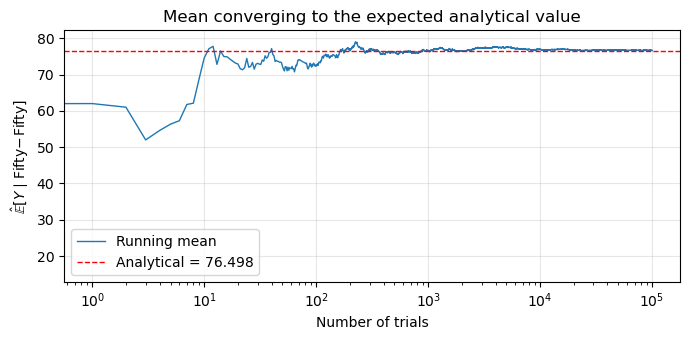

In [10]:
# Running-mean convergence plot
running = np.cumsum(Y_ff) / np.arange(1, N_TRIALS + 1)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(running, lw=1.0, label="Running mean")
ax.axhline(EY_ff_an, color="red", ls="--", lw=1.0,
           label=f"Analytical = {EY_ff_an:.3f}")
ax.set_xscale("log")
ax.set_xlabel("Number of trials")
ax.set_ylabel(r"$\hat{\mathbb{E}}[Y \mid \mathrm{Fifty\!-\!Fifty}]$")
ax.set_title("Mean converging to the expected analytical value")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_running_mean.png", dpi=150)
plt.show()

### Q2 — Sensitivity from soft-pity onset
Change offset and return means, CI, and percentiles.

In [11]:
sensitivity = {}
for onset in CHAR_ONSETS:
    ramp_c = per_pull_probability(onset)
    Ts = run_kit(N_TRIALS, ramp_c, ramp_weapon,
                 seed=SEED + 100 + onset)
    sensitivity[onset] = {
        "samples": Ts,
        "mean": float(Ts.mean()),
        "mean_ci": clt_ci(Ts),
        "q50": float(np.quantile(Ts, 0.50)),
        "q90": float(np.quantile(Ts, 0.90)),
        "q99": float(np.quantile(Ts, 0.99)),
    }

# We will format this into a table so we can check it before moving it to the report.
# Right align for formatting
# Top of table foramt
print(f"{'onset':>6} | {'mean':>9} | {'95% CI':>22} | {'Q50':>6} | {'Q90':>6} | {'Q99':>6}")

# Table Data formatting
for onset in CHAR_ONSETS:
    r = sensitivity[onset]
    ci = f"[{r['mean_ci'][0]:.2f},{r['mean_ci'][1]:.2f}]"
    print(f"{onset:>6} | {r['mean']:>9.2f} | {ci:>22} | {r['q50']:>6.1f} | "
          f"{r['q90']:>6.1f} | {r['q99']:>6.1f}")

 onset |      mean |                 95% CI |    Q50 |    Q90 |    Q99
    50 |    121.99 |        [121.75,122.23] |  124.0 |  179.0 |  190.0
    60 |    129.86 |        [129.60,130.13] |  133.0 |  195.0 |  206.0
    70 |    137.31 |        [137.02,137.60] |  141.0 |  211.0 |  221.0


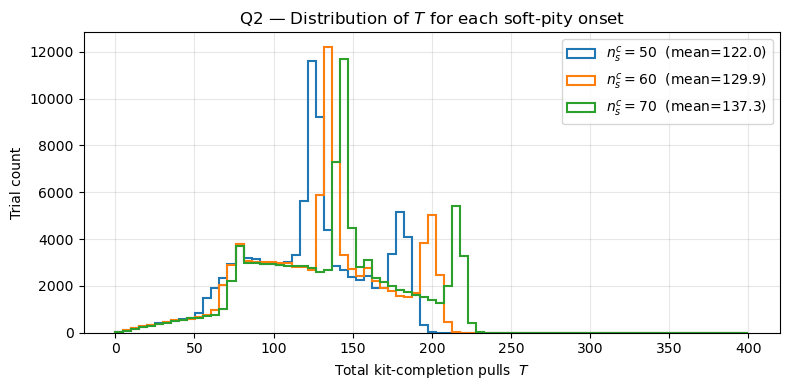

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 400, 80)
for onset in CHAR_ONSETS:
    s = sensitivity[onset]["samples"]
    ax.hist(s, bins=bins, histtype="step", lw=1.5,
            label=f"$n_s^c={onset}$  (mean={s.mean():.1f})")
ax.set_xlabel("Total kit-completion pulls  $T$")
ax.set_ylabel("Trial count")
ax.set_title("Q2 — Distribution of $T$ for each soft-pity onset")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_sensitivity.png", dpi=150)
plt.show()

## Save results to JSON
We cache the values just to make using the values consistent and for safety.

In [13]:
# Below is all code used to create a JSON summary for the sake of caching.

# Converts numpy types in `x` recursively to JSON-serializable Python types -> returns the converted object
def python_to_json_prep(x):
    if isinstance(x, dict):
        return {k: python_to_json_prep(v) for k, v in x.items()
                if not isinstance(v, np.ndarray)}
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, (np.integer,)):  return int(x)
    if isinstance(x, tuple): return [python_to_json_prep(v) for v in x]
    if isinstance(x, list):  return [python_to_json_prep(v) for v in x]
    return x


summary = {
    "parameters": {
        "seed": SEED, "n_trials": N_TRIALS, "p0": P0, "hard_pity": HARD_PITY,
        "char_onsets": list(CHAR_ONSETS),
        "char_onset_baseline": CHAR_ONSET_BASELINE,
        "weapon_onset": WEAPON_ONSET,
    },
    "validation": {
        "EN_analytical": expected_N(ramp_char_baseline),
        "E_Y_fifty_fifty": {"simulated": float(Y_ff.mean()),
                            "ci95": list(ci_ff),
                            "analytical": EY_ff_an},
        "E_Y_guarantee":   {"simulated": float(Y_guar.mean()),
                            "ci95": list(ci_guar),
                            "analytical": EY_guar_an},
    },
    "sensitivity": python_to_json_prep(sensitivity),
}

with open(OUT_DIR / "results.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Wrote {OUT_DIR / 'results.json'}")

Wrote outputs/results.json
